# **Model Building - Prophet**

Prophet is a decomposition-based forecasting model that automatically separates a time series into trend, weekly seasonality, and yearly seasonality components, requiring less manual feature engineering than XGBoost.

In [1]:
import pandas as pd 
train = pd.read_csv('/kaggle/input/datasets/sanyazuberi/ev-charging-train-test-split/train.csv', index_col=0, parse_dates=True)
test = pd.read_csv('/kaggle/input/datasets/sanyazuberi/ev-charging-train-test-split/test.csv', index_col=0, parse_dates=True)

**Installing and importing Prophet**  
Prophet is not pre-installed in Colab by default, so it's installed via pip before importing.

In [2]:
!pip install prophet
from prophet import Prophet

**Define a reusable function to train, predict, and evaluate**  
Since session count and energy required identical modelling steps on different columns, I wrote this as a single reusable function rather than duplicating the same code twice. This keeps the logic in one place. Any future fix or setting change only needs to happen once and will be automatically applied to both targets.  
The function prepares the data into Prophet’s required ds/y format, trains a model using multiplicative seasonality, generates predictions across the full timeline, then isolates just the test-period predictions and calculates RMSE and MAPE against the actual values. MAPE is calculated excluding hours where actual demand was zero, since MAPE is undefined when dividing by zero. This is an issue for this dataset, as overnight hours frequently have zero sessions.


In [3]:
import matplotlib.pyplot as plt 

def run_prophet_multiplicative(train_df, test_df, target_col):
  prophet_train = train_df.reset_index()[['start_timestamp', target_col]]
  prophet_train = prophet_train.rename(columns = {'start_timestamp' : 'ds', target_col: 'y'})

  prophet_test = test_df.reset_index()[['start_timestamp', target_col]]
  prophet_test = prophet_test.rename(columns = {'start_timestamp' : 'ds', target_col: 'y'})

  model = Prophet(seasonality_mode= 'multiplicative')
  model.fit(prophet_train)

  future = model.make_future_dataframe(periods = len(prophet_test), freq = 'h')
  forecast = model.predict(future)
  forecast_test = forecast.tail(len(prophet_test))

  comparison = prophet_test.merge(forecast_test[['ds', 'yhat']], on= 'ds')
  comparison.head()

  from sklearn.metrics import mean_absolute_percentage_error , root_mean_squared_error

  rmse = root_mean_squared_error(comparison['y'], comparison['yhat'])
  print(f"Prophet (multiplicative) RMSE: {rmse:.4f}")

  nonzero_mask = comparison['y'] != 0
  mape = mean_absolute_percentage_error(
      comparison.loc[nonzero_mask,'y'],
      comparison.loc[nonzero_mask, 'yhat'])

  return model, comparison, rmse, mape

**Additive vs. Multiplicative Seasonality**  
An initial version using Prophet’s (additive) seasonality significantly underfit the data: predictions stayed within a narrow, roughly flat band while actual demand swung far more widely across each day (RMSE ≈ 60.6). Using Prophet’s plot_components diagnostic, the daily seasonal components were found to have a small, fixed amplitude that did not scale with the network’s growth over time.  
Based on this, I switched to multiplicative seasonality, where seasonal swings scale proportionally with the trend level, appropriate given the network roughly quadrupled in size over the 3-year period. This reduced RMSE by approximately 8x for session count (≈ 60.6 to5.26), confirming that seasonal amplitude does grow with network demand rather than staying fixed.  
I also tested increasing trend flexibility (changepoint_prior_scale=0.5), aimed at helping the model better capture the step-changes from new station rollouts. This produced no meaningful improvement (RMSE 5.13 vs. 5.26; MAPE 0.414 vs. 0.409), so the simpler default changepoint setting was retained.

**Plotting actual vs. predicted**  
A second reusable function handles the plotting, again to avoid duplicating the same matplotlib code for both targets. It overlays actual and predicted values on a single chart with a readable, weekly-spaced date axis.

In [4]:
import matplotlib.dates as mdates

def plot_prophet_result(comparison_df, target_label, ylabel):
  plt.figure(figsize=(16,5))
  plt.plot(comparison_df['ds'], comparison_df['y'], label='Actual', alpha=0.8)
  plt.plot(comparison_df['ds'], comparison_df['yhat'], label='Predicted (multiplicative)', alpha=0.8)
  plt.legend()
  plt.title(f'Prophet (Multiplicative Seasonality): Actual vs {target_label}')
  plt.xlabel('Date')
  plt.ylabel(ylabel)

  ax = plt.gca()
  ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
  ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()

**Running both targets**  
The function is called once for session_count and once for total_energy_kwh, using the same training/test split and the same multiplicative seasonality setting for both.

In [5]:
model_session, comparison_session, rmse_session_prophet, mape_session_prophet = run_prophet_multiplicative(
    train, test, 'session_count'
)

model_energy, comparison_energy, rmse_energy_prophet, mape_energy_prophet = run_prophet_multiplicative(
    train, test, 'total_energy_kwh'
)

15:08:54 - cmdstanpy - INFO - Chain [1] start processing
15:09:24 - cmdstanpy - INFO - Chain [1] done processing


Prophet (multiplicative) RMSE: 5.3141


15:09:32 - cmdstanpy - INFO - Chain [1] start processing
15:09:52 - cmdstanpy - INFO - Chain [1] done processing


Prophet (multiplicative) RMSE: 262.1386


**Plotting both results**  


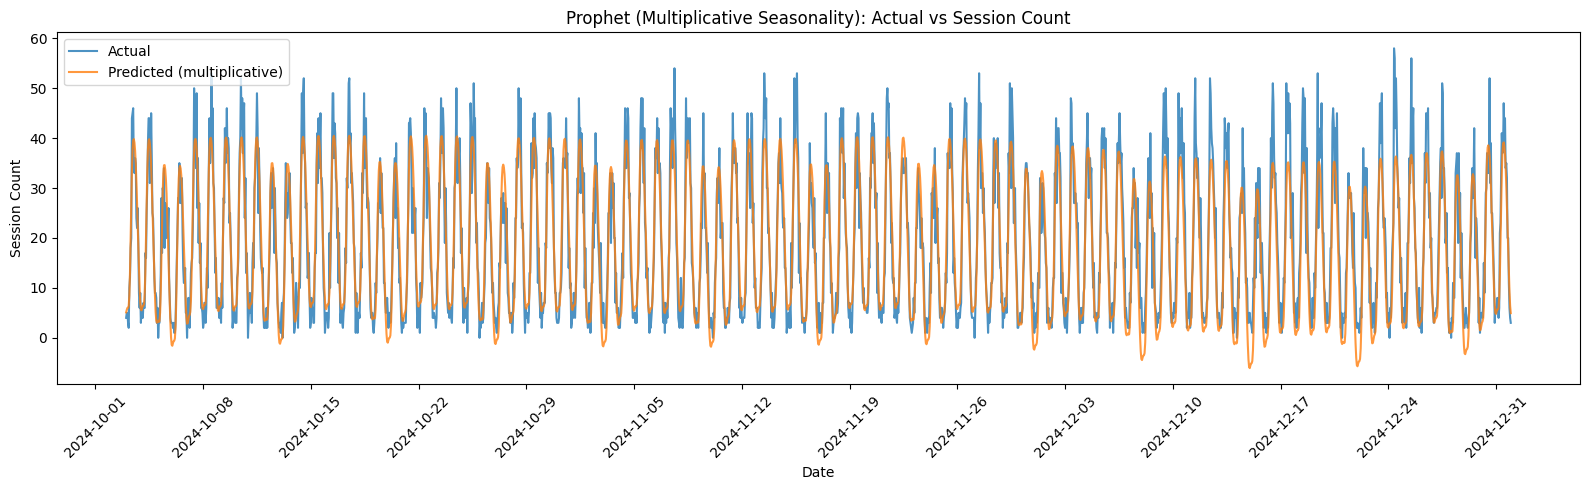

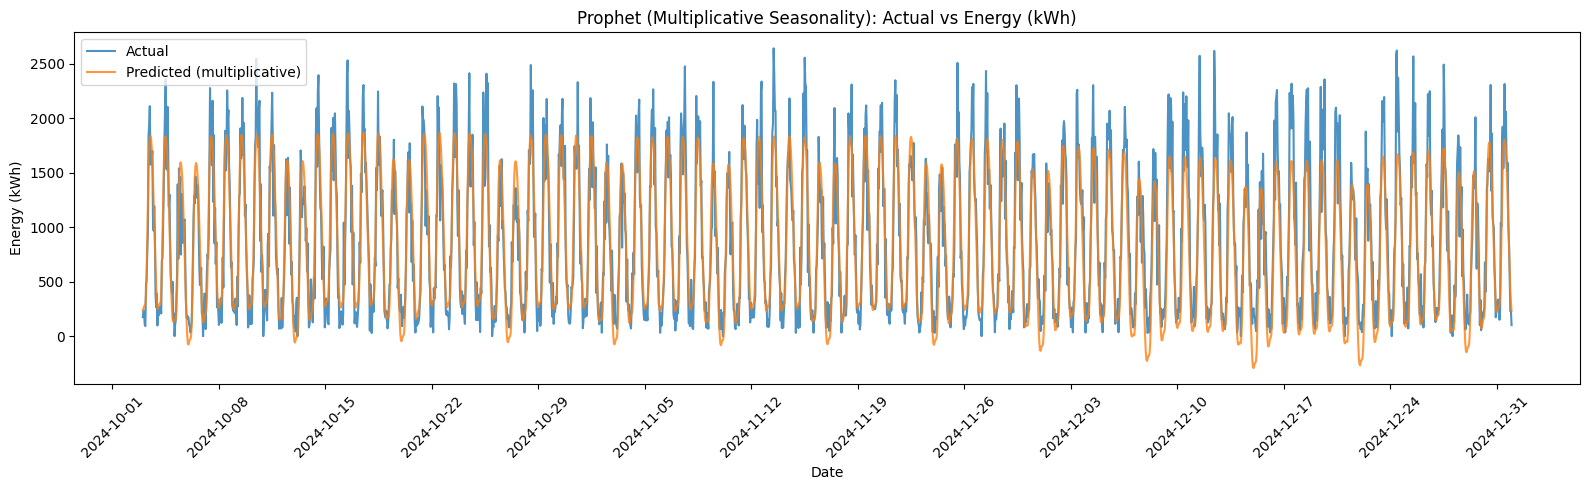

In [6]:
plot_prophet_result(comparison_session, 'Session Count', 'Session Count')
plot_prophet_result(comparison_energy, 'Energy (kWh)', 'Energy (kWh)')


**Session count:**     
RMSE 5.26, MAPE 40.9% (excluding zero-demand hours). Predictions track the daily and weekly rhythms reasonably well.    
**Energy (kWh):**   
RMSE 261.02. MAPE 44.8% (excluding zero-demand hours). The predicted curve follows the same daily/weekly shape as actual energy demand, but consistently underestimates the heights of the peaks. The actual demand reaches 2000-2600 kWh while predictions cap out closer to 1800 kWh.    
More notably, several predicted troughs dip into negative energy values (visible dips below 0 in November and December, reaching as low as roughly ∼ 250 kWh). This is not physically meaningful, as energy delivered cannot be negative. This is a known side effect of multiplicative seasonality when the trend is low and the seasonal multiplier swings below 1. I’m noting this here as a documented limitation of the current model rather than a data error. Any real deployment of this forecast for procurement purposes would need predictions clipped at a minimum of 0 before use.


**Building the results table**  
Combines RMSE and MAPE for both targets into a single table, providing the Prophet row(s) that later feed into the full model comparison table alongside SARIMA and XGBoost.


In [7]:
results_prophet = pd.DataFrame({
    'target': ['session_count', 'total_energy_kwh'],
    'RMSE': [rmse_session_prophet, rmse_energy_prophet],
    'MAPE': [mape_session_prophet, mape_energy_prophet]
})
results_prophet

,target,RMSE,MAPE
0,session_count,5.314063,0.413010
1,total_energy_kwh,262.138628,0.449249


**Note on reusability:**  
Prophet’s point forecasts (yhat) are deterministic given fixed data and settings. Re-running the model reproduces the same predictions. Only the uncertainty intervals (not used in this analysis) involve some randomness.


In [8]:
# save output for the next notebook
results_prophet.to_csv('/kaggle/working/results_prophet.csv', index=False)
comparison_session.to_csv('/kaggle/working/comparison_session_prophet.csv', index=False)
comparison_energy.to_csv('/kaggle/working/comparison_energy_prophet.csv', index=False)